# CODE CNN CƠ BẢN + 3 MÔ HÌNH CẢI TIẾN TRÊN MNIST

**File dự kiến đặt tại:**

`C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a05\data1_diabetes\preprocessor.ipynb`

**Dataset đầu vào:**

`C:\DATA\mnist`

Notebook này triển khai toàn bộ pipeline cho **MNIST**:

1. Đọc và kiểm tra dữ liệu CSV.
2. Tiền xử lý ảnh từ vector 784 pixel về tensor `N × 1 × 28 × 28`.
3. Chuẩn hóa dữ liệu.
4. Chia tập train/validation.
5. Xây dựng **CNN cơ bản**.
6. Xây dựng **ResNet** với residual block `F(x) + x`.
7. Xây dựng **VGGNet-style** bằng nhiều `Conv 3×3` xếp chồng.
8. Xây dựng **MobileNet-style** bằng `Depthwise + Pointwise 1×1`.
9. Huấn luyện bốn mô hình cùng một protocol để so sánh công bằng.
10. Đánh giá Accuracy, Loss, số tham số, thời gian huấn luyện.
11. Visualization learning curve, confusion matrix và dự đoán mẫu.

> Mỗi code cell có comment tiếng Việt chi tiết để giải thích vai trò của từng lệnh.

## 1. Import thư viện và cấu hình môi trường

Phần này import toàn bộ thư viện cần thiết và đặt random seed để kết quả có khả năng tái lập.

In [1]:
# Import Path để xử lý đường dẫn file theo cách an toàn trên Windows.
from pathlib import Path

# Import time để đo tổng thời gian huấn luyện của từng mô hình.
import time

# Import copy để sao chép state_dict tốt nhất trong quá trình validation.
import copy

# Import random để đặt seed cho Python.
import random

# Import NumPy để xử lý ma trận số và dữ liệu ảnh.
import numpy as np

# Import Pandas để đọc hai file MNIST dạng CSV.
import pandas as pd

# Import Matplotlib để trực quan hóa ảnh, learning curve và biểu đồ so sánh.
import matplotlib.pyplot as plt

# Import PyTorch - thư viện deep learning chính được sử dụng trong notebook.
import torch

# Import torch.nn để xây dựng các layer như Conv2d, Linear, BatchNorm2d, ReLU.
import torch.nn as nn

# Import torch.nn.functional để dùng các hàm functional như relu.
import torch.nn.functional as F

# Import TensorDataset để gói tensor ảnh và tensor nhãn thành dataset.
from torch.utils.data import TensorDataset

# Import DataLoader để chia dataset thành các mini-batch.
from torch.utils.data import DataLoader

# Import train_test_split để chia train/validation có stratify theo nhãn.
from sklearn.model_selection import train_test_split

# Import confusion_matrix để đánh giá lỗi nhầm giữa 10 chữ số.
from sklearn.metrics import confusion_matrix

# Import classification_report để xem precision, recall, F1-score theo từng lớp.
from sklearn.metrics import classification_report

# Đặt seed cố định để phép chia dữ liệu, khởi tạo weight và shuffle có thể tái lập.
SEED = 42

# Đặt seed cho module random của Python.
random.seed(SEED)

# Đặt seed cho NumPy.
np.random.seed(SEED)

# Đặt seed cho PyTorch trên CPU.
torch.manual_seed(SEED)

# Nếu có GPU NVIDIA, đặt thêm seed cho tất cả CUDA device.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Yêu cầu cuDNN ưu tiên thuật toán xác định hơn để tăng khả năng tái lập.
torch.backends.cudnn.deterministic = True

# Tắt benchmark vì benchmark có thể chọn thuật toán khác nhau giữa các lần chạy.
torch.backends.cudnn.benchmark = False

# Chọn GPU nếu máy có CUDA; nếu không thì tự động dùng CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# In device để biết notebook đang huấn luyện bằng CPU hay GPU.
print("DEVICE =", DEVICE)

DEVICE = cpu


## 2. Khai báo đường dẫn dataset

Notebook được thiết kế để đọc dữ liệu tại `C:\DATA\mnist`.

Hàm `resolve_file()` hỗ trợ nhiều tên file thường gặp, ví dụ:

- `mnist_train.csv`
- `train.csv`
- `mnist_train`
- `train`

và tương tự cho tập test.

In [ ]:
# Khai báo thư mục chứa hai file MNIST trên máy Windows.
DATA_DIR = Path(r"C:\DATA\mnist")

# Khai báo các tên file train có thể xuất hiện.
TRAIN_CANDIDATES = [
    "mnist_train.csv",
    "train.csv",
    "mnist_train",
    "train",
]

# Khai báo các tên file test có thể xuất hiện.
TEST_CANDIDATES = [
    "mnist_test.csv",
    "test.csv",
    "mnist_test",
    "test",
]


# Định nghĩa hàm tìm file đầu tiên tồn tại trong danh sách candidate.
def resolve_file(directory: Path, candidates: list[str]) -> Path:
    # Duyệt lần lượt từng tên file có thể có.
    for filename in candidates:
        # Ghép thư mục gốc và tên file thành đường dẫn đầy đủ.
        candidate_path = directory / filename

        # Nếu file thực sự tồn tại thì trả về ngay đường dẫn đó.
        if candidate_path.exists():
            return candidate_path

    # Nếu không tìm thấy file nào thì tạo thông báo lỗi dễ hiểu.
    raise FileNotFoundError(f"Không tìm thấy file trong {directory}. Đã thử các tên: {candidates}")


# Kiểm tra thư mục dataset có tồn tại trước khi đọc.
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Không tồn tại thư mục dataset: {DATA_DIR}\nHãy kiểm tra lại đường dẫn C:\\DATA\\mnist."
    )

# Tự động xác định file train.
TRAIN_FILE = resolve_file(DATA_DIR, TRAIN_CANDIDATES)

# Tự động xác định file test.
TEST_FILE = resolve_file(DATA_DIR, TEST_CANDIDATES)

# In đường dẫn thật của file train để kiểm tra.
print("TRAIN_FILE =", TRAIN_FILE)

# In đường dẫn thật của file test để kiểm tra.
print("TEST_FILE  =", TEST_FILE)

TRAIN_FILE = C:\DATA\mnist\mnist_train.csv
TEST_FILE  = C:\DATA\mnist\mnist_test.csv


## 3. Đọc dữ liệu CSV và kiểm tra cấu trúc

MNIST dạng CSV thường có:

- 1 cột nhãn `label`.
- 784 cột pixel.
- Mỗi hàng tương ứng một ảnh `28 × 28`.

Nếu file không có tên cột `label`, notebook sẽ mặc định **cột đầu tiên là nhãn**.

In [3]:
# Đọc toàn bộ file train bằng Pandas.
train_df = pd.read_csv(TRAIN_FILE)

# Đọc toàn bộ file test bằng Pandas.
test_df = pd.read_csv(TEST_FILE)

# In kích thước bảng train theo dạng (số hàng, số cột).
print("train_df.shape =", train_df.shape)

# In kích thước bảng test.
print("test_df.shape  =", test_df.shape)

# Hiển thị 5 dòng đầu để kiểm tra dữ liệu có đọc đúng hay không.
display(train_df.head())

# In một số tên cột đầu tiên để kiểm tra cấu trúc CSV.
print("Các cột đầu:", train_df.columns[:10].tolist())

train_df.shape = (60000, 785)
test_df.shape  = (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Các cột đầu: ['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9']


## 4. Xác định cột label và 784 pixel

Mục tiêu của bước này là tạo:

- `X_train_raw`: ma trận pixel.
- `y_train_raw`: vector nhãn.
- `X_test_raw`: ma trận pixel test.
- `y_test_raw`: vector nhãn test.

In [ ]:
# Nếu dataset có cột tên chính xác là "label" thì sử dụng cột đó làm target.
if "label" in train_df.columns:
    # Gán tên cột label cho tập train.
    train_label_col = "label"
else:
    # Nếu không có tên "label", mặc định cột đầu tiên là target.
    train_label_col = train_df.columns[0]

# Thực hiện logic tương tự cho tập test.
if "label" in test_df.columns:
    # Gán tên cột label của test.
    test_label_col = "label"
else:
    # Nếu không có tên "label", lấy cột đầu tiên.
    test_label_col = test_df.columns[0]

# Tách toàn bộ cột pixel khỏi tập train và ép về float32.
X_train_raw = train_df.drop(columns=[train_label_col]).to_numpy(dtype=np.float32)

# Tách nhãn train và ép về int64 vì CrossEntropyLoss yêu cầu class index kiểu Long.
y_train_raw = train_df[train_label_col].to_numpy(dtype=np.int64)

# Tách toàn bộ cột pixel khỏi tập test.
X_test_raw = test_df.drop(columns=[test_label_col]).to_numpy(dtype=np.float32)

# Tách nhãn test.
y_test_raw = test_df[test_label_col].to_numpy(dtype=np.int64)

# Kiểm tra mỗi ảnh có đúng 784 pixel = 28 × 28 hay không.
if X_train_raw.shape[1] != 28 * 28:
    raise ValueError(f"Train có {X_train_raw.shape[1]} feature, nhưng MNIST cần đúng 784 pixel.")

# Kiểm tra tập test cũng có đúng 784 pixel.
if X_test_raw.shape[1] != 28 * 28:
    raise ValueError(f"Test có {X_test_raw.shape[1]} feature, nhưng MNIST cần đúng 784 pixel.")

# In shape trước reshape để thấy dữ liệu hiện vẫn đang ở dạng vector phẳng.
print("X_train_raw:", X_train_raw.shape)

# In shape nhãn train.
print("y_train_raw:", y_train_raw.shape)

# In shape input test.
print("X_test_raw :", X_test_raw.shape)

# In shape nhãn test.
print("y_test_raw :", y_test_raw.shape)

# In các class thực tế xuất hiện trong tập train.
print("Classes:", np.unique(y_train_raw))

X_train_raw: (60000, 784)
y_train_raw: (60000,)
X_test_raw : (10000, 784)
y_test_raw : (10000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


## 5. Tiền xử lý ảnh MNIST

Theo cấu trúc MNIST, mỗi ảnh đang là vector 784 phần tử. Ta thực hiện:

`[N, 784] → [N, 1, 28, 28]`

Sau đó:

1. Chia pixel cho `255`.
2. Tính `mean` và `std` **chỉ trên tập train**.
3. Normalize train và test bằng cùng mean/std.

Việc tính thống kê chỉ từ train giúp tránh sử dụng thông tin của test trong tiền xử lý.

In [5]:
# Chia pixel train từ miền [0, 255] về miền [0, 1].
X_train_scaled = X_train_raw / 255.0

# Chia pixel test từ miền [0, 255] về miền [0, 1].
X_test_scaled = X_test_raw / 255.0

# Tính mean của pixel dựa CHỈ trên dữ liệu train.
train_mean = float(X_train_scaled.mean())

# Tính standard deviation dựa CHỈ trên dữ liệu train.
train_std = float(X_train_scaled.std())

# Kiểm tra std không quá nhỏ để tránh chia cho 0.
if train_std < 1e-8:
    raise ValueError("Standard deviation quá nhỏ, không thể normalize.")

# Normalize tập train về xấp xỉ mean 0 và std 1.
X_train_norm = (X_train_scaled - train_mean) / train_std

# Normalize tập test bằng đúng thống kê train.
X_test_norm = (X_test_scaled - train_mean) / train_std

# Reshape train từ [N, 784] thành [N, 1, 28, 28].
X_train_norm = X_train_norm.reshape(-1, 1, 28, 28)

# Reshape test từ [N, 784] thành [N, 1, 28, 28].
X_test_norm = X_test_norm.reshape(-1, 1, 28, 28)

# In mean để lưu lại thông số tiền xử lý.
print("train_mean =", train_mean)

# In std để lưu lại thông số tiền xử lý.
print("train_std  =", train_std)

# Kiểm tra shape sau reshape.
print("X_train_norm.shape =", X_train_norm.shape)

# Kiểm tra shape test sau reshape.
print("X_test_norm.shape  =", X_test_norm.shape)

train_mean = 0.13066047430038452
train_std  = 0.30810779333114624
X_train_norm.shape = (60000, 1, 28, 28)
X_test_norm.shape  = (10000, 1, 28, 28)


## 6. Chia tập train thành train/validation

Tập test được giữ nguyên để đánh giá cuối cùng.

Từ tập train ban đầu, notebook dành **10% làm validation**.  
`stratify=y_train_raw` giúp tỷ lệ 10 chữ số gần tương đương giữa train và validation.

In [ ]:
# Tạo vector index từ 0 đến số mẫu train - 1.
all_indices = np.arange(len(y_train_raw))

# Chia index thành hai tập train và validation.
train_indices, val_indices = train_test_split(
    # Mảng index cần chia.
    all_indices,
    # Dành 10% dữ liệu train ban đầu cho validation.
    test_size=0.10,
    # Dùng seed cố định để lần sau chia giống lần trước.
    random_state=SEED,
    # Giữ tỷ lệ các class tương đối đồng đều.
    stratify=y_train_raw,
)

# Lấy ảnh train theo train_indices.
X_train = X_train_norm[train_indices]

# Lấy nhãn train tương ứng.
y_train = y_train_raw[train_indices]

# Lấy ảnh validation.
X_val = X_train_norm[val_indices]

# Lấy nhãn validation.
y_val = y_train_raw[val_indices]

# Gán tập test đã normalize.
X_test = X_test_norm

# Gán nhãn test.
y_test = y_test_raw

# In số mẫu train cuối cùng.
print("Train:", X_train.shape, y_train.shape)

# In số mẫu validation.
print("Val  :", X_val.shape, y_val.shape)

# In số mẫu test.
print("Test :", X_test.shape, y_test.shape)

Train: (54000, 1, 28, 28) (54000,)
Val  : (6000, 1, 28, 28) (6000,)
Test : (10000, 1, 28, 28) (10000,)


## 7. Tùy chọn chạy nhanh khi debug

Khi mới kiểm tra notebook, có thể bật `FAST_DEBUG = True` để chỉ huấn luyện trên một phần dữ liệu.

Khi chạy báo cáo chính thức, giữ `FAST_DEBUG = False`.

In [7]:
# Đặt False để huấn luyện toàn bộ dữ liệu.
FAST_DEBUG = False

# Nếu chỉ muốn test code nhanh, có thể đổi thành True.
if FAST_DEBUG:
    # Giới hạn train còn 10.000 mẫu.
    X_train = X_train[:10_000]

    # Giới hạn nhãn train tương ứng.
    y_train = y_train[:10_000]

    # Giới hạn validation còn 2.000 mẫu.
    X_val = X_val[:2_000]

    # Giới hạn nhãn validation tương ứng.
    y_val = y_val[:2_000]

    # Giới hạn test còn 2.000 mẫu.
    X_test = X_test[:2_000]

    # Giới hạn nhãn test tương ứng.
    y_test = y_test[:2_000]

# In lại số mẫu thực tế sẽ dùng sau chế độ debug.
print("Số mẫu thực tế:")
print("train =", len(X_train))
print("val   =", len(X_val))
print("test  =", len(X_test))

Số mẫu thực tế:
train = 54000
val   = 6000
test  = 10000


## 8. Chuyển NumPy sang PyTorch Tensor và tạo DataLoader

`DataLoader` giúp:

- Chia dữ liệu thành mini-batch.
- Shuffle train.
- Không shuffle validation/test.
- Đưa từng batch vào training loop.

In [8]:
# Chuyển ảnh train từ NumPy float32 sang PyTorch tensor.
train_x_tensor = torch.from_numpy(X_train).float()

# Chuyển nhãn train sang torch.long để dùng với CrossEntropyLoss.
train_y_tensor = torch.from_numpy(y_train).long()

# Chuyển ảnh validation sang tensor.
val_x_tensor = torch.from_numpy(X_val).float()

# Chuyển nhãn validation sang tensor long.
val_y_tensor = torch.from_numpy(y_val).long()

# Chuyển ảnh test sang tensor.
test_x_tensor = torch.from_numpy(X_test).float()

# Chuyển nhãn test sang tensor long.
test_y_tensor = torch.from_numpy(y_test).long()

# Gói ảnh và nhãn train thành một TensorDataset.
train_dataset = TensorDataset(train_x_tensor, train_y_tensor)

# Gói validation thành TensorDataset.
val_dataset = TensorDataset(val_x_tensor, val_y_tensor)

# Gói test thành TensorDataset.
test_dataset = TensorDataset(test_x_tensor, test_y_tensor)

# Đặt batch size chung cho tất cả mô hình để so sánh công bằng.
BATCH_SIZE = 128

# num_workers=0 là lựa chọn an toàn khi chạy Jupyter Notebook trên Windows.
NUM_WORKERS = 0

# Chỉ bật pin_memory khi dùng CUDA để tăng tốc copy dữ liệu CPU -> GPU.
PIN_MEMORY = DEVICE.type == "cuda"

# DataLoader train có shuffle=True để mỗi epoch thay đổi thứ tự mẫu.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

# Validation không cần shuffle vì chỉ dùng để đo metric.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

# Test cũng không shuffle để thuận tiện đối chiếu prediction.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

# Lấy thử một batch đầu tiên để kiểm tra shape.
sample_images, sample_labels = next(iter(train_loader))

# In shape ảnh phải có dạng [batch, 1, 28, 28].
print("sample_images.shape =", sample_images.shape)

# In shape nhãn phải có dạng [batch].
print("sample_labels.shape =", sample_labels.shape)

sample_images.shape = torch.Size([128, 1, 28, 28])
sample_labels.shape = torch.Size([128])


C:\Users\datng\AppData\Local\Temp\ipykernel_84408\3687534168.py:17: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  test_y_tensor = torch.from_numpy(y_test).long()


## 9. Visualization dữ liệu trước huấn luyện

Ta đảo normalize để ảnh hiển thị trở lại gần miền `[0, 1]`.

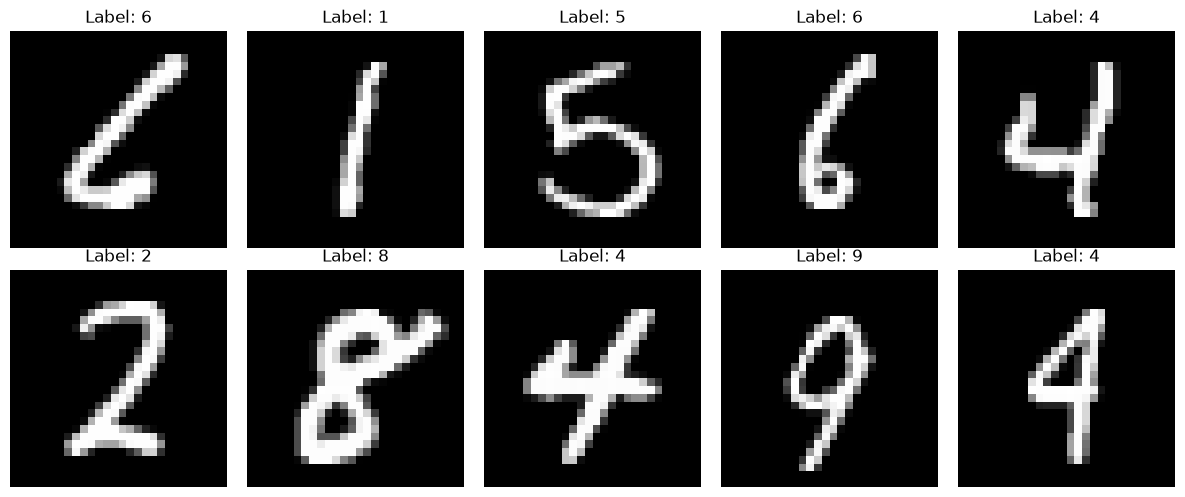

In [9]:
# Tạo một figure để hiển thị một số ảnh MNIST.
plt.figure(figsize=(12, 5))

# Duyệt 10 ảnh đầu tiên của batch mẫu.
for i in range(10):
    # Tạo vị trí thứ i trong lưới 2 hàng × 5 cột.
    plt.subplot(2, 5, i + 1)

    # Lấy tensor ảnh [1, 28, 28] và bỏ channel dimension thành [28, 28].
    image = sample_images[i].squeeze(0).numpy()

    # Đảo normalize: x_normalized * std + mean.
    image = image * train_std + train_mean

    # Giới hạn giá trị về [0, 1] để hiển thị đúng thang xám.
    image = np.clip(image, 0.0, 1.0)

    # Hiển thị ảnh bằng colormap gray.
    plt.imshow(image, cmap="gray")

    # Dùng nhãn thật làm title.
    plt.title(f"Label: {sample_labels[i].item()}")

    # Ẩn trục vì ảnh chữ số không cần tọa độ.
    plt.axis("off")

# Tự động căn khoảng cách giữa các ô.
plt.tight_layout()

# Hiển thị figure.
plt.show()

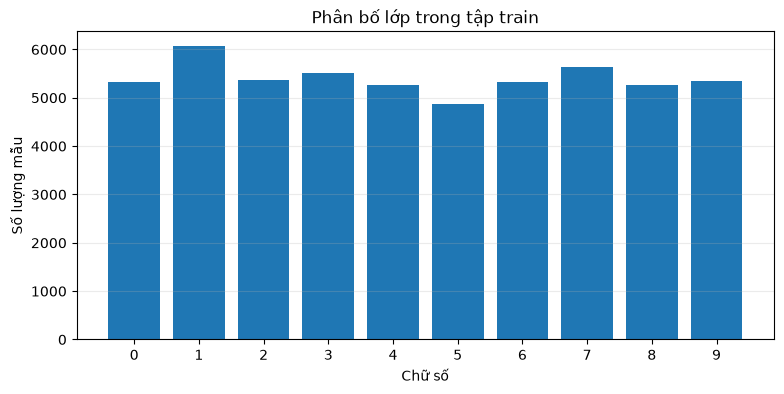

In [10]:
# Đếm số mẫu của từng chữ số 0-9 trong tập train.
class_counts = np.bincount(y_train, minlength=10)

# Tạo figure mới cho biểu đồ phân bố class.
plt.figure(figsize=(9, 4))

# Vẽ bar chart với trục x là chữ số và trục y là số lượng mẫu.
plt.bar(np.arange(10), class_counts)

# Đặt tick từ 0 đến 9.
plt.xticks(np.arange(10))

# Đặt tên trục x.
plt.xlabel("Chữ số")

# Đặt tên trục y.
plt.ylabel("Số lượng mẫu")

# Đặt tiêu đề biểu đồ.
plt.title("Phân bố lớp trong tập train")

# Bật lưới ngang mờ để dễ đọc giá trị.
plt.grid(axis="y", alpha=0.25)

# Hiển thị biểu đồ.
plt.show()

# PHẦN B — CODE CNN CƠ BẢN + 3 MÔ HÌNH CẢI TIẾN

Bốn mô hình đều nhận input:

`[N, 1, 28, 28]`

và trả output:

`[N, 10]`

Output cuối là **logits**, không Softmax trước `CrossEntropyLoss`.

## 10. Mô hình 1 — CNN cơ bản

Pipeline:

`Conv → ReLU → Pool → Conv → ReLU → Pool → Flatten → Linear → ReLU → Dropout → Linear`

In [11]:
# Định nghĩa một lớp CNN cơ bản kế thừa nn.Module.
class BasicCNN(nn.Module):
    # Hàm __init__ khai báo các layer có tham số của mạng.
    def __init__(self, num_classes: int = 10):
        # Gọi constructor của nn.Module.
        super().__init__()

        # Conv1 nhận ảnh 1 channel và tạo 32 feature map.
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        # Conv2 tăng số channel từ 32 lên 64.
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        # MaxPool 2×2 giảm chiều cao và chiều rộng còn một nửa.
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )

        # Sau hai lần pooling: 28 -> 14 -> 7.
        # Tensor trước FC có shape [N, 64, 7, 7].
        # Do đó số feature sau flatten là 64 × 7 × 7.
        self.fc1 = nn.Linear(
            in_features=64 * 7 * 7,
            out_features=128,
        )

        # Dropout giảm overfitting bằng cách ngẫu nhiên bỏ activation khi training.
        self.dropout = nn.Dropout(p=0.30)

        # Linear cuối tạo 10 logits tương ứng 10 chữ số.
        self.fc2 = nn.Linear(
            in_features=128,
            out_features=num_classes,
        )

    # forward mô tả luồng tensor đi qua mạng.
    def forward(self, x):
        # Conv1 học các pattern cục bộ ban đầu.
        x = self.conv1(x)

        # ReLU đưa phi tuyến vào mạng.
        x = F.relu(x)

        # Pool giảm 28×28 thành 14×14.
        x = self.pool(x)

        # Conv2 học feature mức cao hơn.
        x = self.conv2(x)

        # ReLU sau Conv2.
        x = F.relu(x)

        # Pool lần hai giảm 14×14 thành 7×7.
        x = self.pool(x)

        # Flatten giữ batch dimension và trải các feature còn lại thành vector.
        x = torch.flatten(x, start_dim=1)

        # Fully connected đầu tiên.
        x = self.fc1(x)

        # ReLU sau fc1.
        x = F.relu(x)

        # Dropout chỉ có tác dụng khi model.train().
        x = self.dropout(x)

        # Linear cuối trả 10 logits.
        logits = self.fc2(x)

        # Không Softmax ở đây vì CrossEntropyLoss nhận trực tiếp logits.
        return logits

## 11. Mô hình 2 — ResNet

Ý tưởng cốt lõi:

`y = F(x) + x`

Nếu shape thay đổi:

`y = F(x) + projection(x)`

Trong implementation bên dưới, projection dùng `Conv 1×1` khi stride hoặc số channel thay đổi.

In [12]:
# Định nghĩa BasicBlock - building block residual dùng hai Conv 3×3.
class BasicBlock(nn.Module):
    # Constructor nhận số channel đầu vào, đầu ra và stride.
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        # Gọi constructor của nn.Module.
        super().__init__()

        # Conv đầu tiên có thể dùng stride=2 để downsample khi chuyển stage.
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        # BatchNorm chuẩn hóa activation theo từng output channel.
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Conv thứ hai luôn stride=1 để giữ shape trong residual branch.
        self.conv2 = nn.Conv2d(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )

        # BatchNorm thứ hai được đặt trước phép cộng residual.
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Nếu spatial size hoặc channel thay đổi, shortcut không thể cộng trực tiếp với F(x).
        if stride != 1 or in_channels != out_channels:
            # Dùng projection shortcut bằng Conv 1×1 để khớp shape.
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            # Nếu shape giữ nguyên thì shortcut chính là identity x.
            self.shortcut = nn.Identity()

    # forward thực hiện residual learning.
    def forward(self, x):
        # Tạo nhánh shortcut trước để lưu identity/projection(x).
        identity = self.shortcut(x)

        # Conv 3×3 thứ nhất.
        out = self.conv1(x)

        # BatchNorm sau conv1.
        out = self.bn1(out)

        # ReLU sau BN1.
        out = F.relu(out)

        # Conv 3×3 thứ hai.
        out = self.conv2(out)

        # BatchNorm thứ hai.
        out = self.bn2(out)

        # Phép cộng cốt lõi của ResNet: F(x) + x hoặc F(x) + projection(x).
        out = out + identity

        # ReLU sau phép cộng residual.
        out = F.relu(out)

        # Trả tensor output của block.
        return out

In [13]:
# Định nghĩa một ResNet nhỏ phù hợp với ảnh MNIST 28×28.
class ResNetMNIST(nn.Module):
    # Constructor nhận số class đầu ra.
    def __init__(self, num_classes: int = 10):
        # Gọi constructor cha.
        super().__init__()

        # Stem conv chuyển ảnh grayscale 1 channel thành 32 channel.
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        # Stage 1 giữ shape [N, 32, 28, 28].
        self.layer1 = nn.Sequential(
            BasicBlock(32, 32, stride=1),
            BasicBlock(32, 32, stride=1),
        )

        # Stage 2 giảm 28×28 -> 14×14 và tăng channel 32 -> 64.
        self.layer2 = nn.Sequential(
            BasicBlock(32, 64, stride=2),
            BasicBlock(64, 64, stride=1),
        )

        # Stage 3 giảm 14×14 -> 7×7 và tăng channel 64 -> 128.
        self.layer3 = nn.Sequential(
            BasicBlock(64, 128, stride=2),
            BasicBlock(128, 128, stride=1),
        )

        # AdaptiveAvgPool gom mỗi feature map về 1×1.
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Linear cuối map 128 feature thành 10 logits.
        self.fc = nn.Linear(128, num_classes)

    # forward mô tả luồng dữ liệu qua các residual stage.
    def forward(self, x):
        # Qua stem.
        x = self.stem(x)

        # Qua residual stage 1.
        x = self.layer1(x)

        # Qua residual stage 2.
        x = self.layer2(x)

        # Qua residual stage 3.
        x = self.layer3(x)

        # Global average pooling về [N, 128, 1, 1].
        x = self.avg_pool(x)

        # Flatten thành [N, 128].
        x = torch.flatten(x, start_dim=1)

        # Tạo logits [N, 10].
        logits = self.fc(x)

        # Trả logits.
        return logits

## 12. Mô hình 3 — VGGNet-style

VGG sử dụng nhiều `Conv 3×3` đơn giản xếp chồng.

Notebook dùng bản **VGG-style rút gọn cho MNIST**, vì input chỉ có `28×28`, nhỏ hơn nhiều so với ảnh ImageNet `224×224`.

Mỗi block:

`(Conv3×3 → ReLU) × n → MaxPool2×2`

In [14]:
# Hàm tạo một VGG block với nhiều Conv 3×3 liên tiếp.
def make_vgg_block(
    in_channels: int,
    out_channels: int,
    num_convs: int,
):
    # Tạo list rỗng để tích lũy các layer.
    layers = []

    # Lặp đúng num_convs lần để thêm các Conv 3×3.
    for conv_index in range(num_convs):
        # Conv đầu block dùng in_channels gốc; các conv sau nhận out_channels.
        current_in = in_channels if conv_index == 0 else out_channels

        # Thêm Conv 3×3, padding=1 để giữ nguyên H×W.
        layers.append(
            nn.Conv2d(
                in_channels=current_in,
                out_channels=out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
            )
        )

        # Thêm ReLU sau từng convolution.
        layers.append(nn.ReLU(inplace=True))

    # Kết thúc block bằng MaxPool để giảm H và W khoảng một nửa.
    layers.append(
        nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )
    )

    # Đóng gói toàn bộ danh sách layer thành một nn.Sequential.
    return nn.Sequential(*layers)

In [15]:
# Định nghĩa VGG-style cho MNIST.
class VGGMNIST(nn.Module):
    # Constructor nhận số class.
    def __init__(self, num_classes: int = 10):
        # Gọi constructor của nn.Module.
        super().__init__()

        # Block 1: hai Conv 3×3, channel 1 -> 32, sau pool 28 -> 14.
        self.block1 = make_vgg_block(
            in_channels=1,
            out_channels=32,
            num_convs=2,
        )

        # Block 2: hai Conv 3×3, channel 32 -> 64, sau pool 14 -> 7.
        self.block2 = make_vgg_block(
            in_channels=32,
            out_channels=64,
            num_convs=2,
        )

        # Block 3: ba Conv 3×3, channel 64 -> 128, sau pool 7 -> 3.
        self.block3 = make_vgg_block(
            in_channels=64,
            out_channels=128,
            num_convs=3,
        )

        # AdaptiveAvgPool tránh phụ thuộc cứng vào spatial shape cuối.
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier nhỏ hơn VGG16 gốc để phù hợp MNIST.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.30),
            nn.Linear(128, num_classes),
        )

    # forward chạy tensor qua các VGG block.
    def forward(self, x):
        # Qua block 1.
        x = self.block1(x)

        # Qua block 2.
        x = self.block2(x)

        # Qua block 3.
        x = self.block3(x)

        # Global average pooling.
        x = self.avg_pool(x)

        # Classifier tạo logits.
        logits = self.classifier(x)

        # Trả logits.
        return logits

## 13. Mô hình 4 — MobileNet-style

MobileNet v1 tách Standard Convolution thành:

1. **Depthwise Conv 3×3**: lọc không gian độc lập từng channel.
2. **Pointwise Conv 1×1**: trộn thông tin giữa các channel.

Trong PyTorch:

`groups = in_channels`

là cách tạo depthwise convolution.

In [16]:
# Định nghĩa block Depthwise Separable Convolution kiểu MobileNet v1.
class DepthwiseSeparableBlock(nn.Module):
    # Constructor nhận số channel input/output và stride.
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
    ):
        # Gọi constructor cha.
        super().__init__()

        # Depthwise branch chỉ lọc từng channel độc lập.
        self.depthwise = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=in_channels,
                kernel_size=3,
                stride=stride,
                padding=1,
                groups=in_channels,
                bias=False,
            ),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
        )

        # Pointwise Conv 1×1 dùng để trộn channel và đổi số output channel.
        self.pointwise = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    # forward thực hiện depthwise trước rồi pointwise.
    def forward(self, x):
        # Spatial filtering độc lập từng channel.
        x = self.depthwise(x)

        # Channel mixing bằng Conv 1×1.
        x = self.pointwise(x)

        # Trả output.
        return x

In [17]:
# Định nghĩa MobileNet-style nhỏ cho MNIST.
class MobileNetMNIST(nn.Module):
    # Constructor nhận số class.
    def __init__(self, num_classes: int = 10):
        # Gọi constructor nn.Module.
        super().__init__()

        # Lớp đầu là standard Conv để tăng channel từ 1 lên 32.
        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        # Block 1 giữ spatial size và tăng 32 -> 64 channel.
        self.block1 = DepthwiseSeparableBlock(
            in_channels=32,
            out_channels=64,
            stride=1,
        )

        # Block 2 downsample 28 -> 14 và tăng 64 -> 128.
        self.block2 = DepthwiseSeparableBlock(
            in_channels=64,
            out_channels=128,
            stride=2,
        )

        # Block 3 giữ 14×14.
        self.block3 = DepthwiseSeparableBlock(
            in_channels=128,
            out_channels=128,
            stride=1,
        )

        # Block 4 downsample 14 -> 7 và tăng 128 -> 256.
        self.block4 = DepthwiseSeparableBlock(
            in_channels=128,
            out_channels=256,
            stride=2,
        )

        # Block 5 giữ 7×7.
        self.block5 = DepthwiseSeparableBlock(
            in_channels=256,
            out_channels=256,
            stride=1,
        )

        # Global average pooling về 1×1.
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Linear cuối biến 256 feature thành 10 logits.
        self.fc = nn.Linear(256, num_classes)

    # forward định nghĩa pipeline MobileNet-style.
    def forward(self, x):
        # Standard convolution đầu tiên.
        x = self.stem(x)

        # Depthwise separable block thứ nhất.
        x = self.block1(x)

        # Depthwise separable block thứ hai.
        x = self.block2(x)

        # Depthwise separable block thứ ba.
        x = self.block3(x)

        # Depthwise separable block thứ tư.
        x = self.block4(x)

        # Depthwise separable block thứ năm.
        x = self.block5(x)

        # Global average pooling.
        x = self.avg_pool(x)

        # Flatten về [N, 256].
        x = torch.flatten(x, start_dim=1)

        # Linear tạo logits.
        logits = self.fc(x)

        # Trả logits.
        return logits

## 14. Kiểm tra forward pass và số tham số

Trước khi train, phải chắc chắn mọi model đều:

- Nhận `[N, 1, 28, 28]`.
- Trả `[N, 10]`.
- Không lỗi shape.

In [ ]:
# Hàm đếm tổng số learnable parameters của một model.
def count_parameters(model: nn.Module) -> int:
    # p.numel() trả số phần tử trong từng parameter tensor.
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Khởi tạo bốn model trong dictionary để dễ lặp.
models = {
    "CNN cơ bản": BasicCNN(num_classes=10),
    "ResNet": ResNetMNIST(num_classes=10),
    "VGGNet": VGGMNIST(num_classes=10),
    "MobileNet": MobileNetMNIST(num_classes=10),
}

# Tạo dummy batch gồm 4 ảnh MNIST.
dummy_x = torch.randn(4, 1, 28, 28)

# Duyệt từng model để kiểm tra.
for model_name, model in models.items():
    # Tắt gradient vì đây chỉ là forward test.
    with torch.no_grad():
        # Chạy dummy input qua model.
        dummy_logits = model(dummy_x)

    # In tên model.
    print(f"\n{model_name}")

    # In shape output; kỳ vọng [4, 10].
    print("Output shape:", tuple(dummy_logits.shape))

    # In số tham số learnable.
    print("Parameters:", f"{count_parameters(model):,}")

    # Nếu shape sai thì dừng notebook ngay.
    assert dummy_logits.shape == (4, 10)


CNN cơ bản
Output shape: (4, 10)
Parameters: 421,642

ResNet
Output shape: (4, 10)
Parameters: 696,042

VGGNet
Output shape: (4, 10)
Parameters: 451,818

MobileNet
Output shape: (4, 10)
Parameters: 136,202


# PHẦN C — TRAINING, ĐÁNH GIÁ, SO SÁNH VÀ VISUALIZATION

## 15. Hàm train một epoch

Một iteration thực hiện:

`batch → forward → loss → zero_grad → backward → optimizer.step`

In [19]:
# Hàm huấn luyện model đúng một epoch.
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
):
    # Chuyển model sang training mode để Dropout/BatchNorm hoạt động đúng.
    model.train()

    # Biến cộng dồn tổng loss có trọng số theo batch size.
    running_loss = 0.0

    # Biến đếm số prediction đúng.
    running_correct = 0

    # Biến đếm tổng số mẫu đã xử lý.
    running_total = 0

    # Duyệt từng mini-batch.
    for images, labels in loader:
        # Chuyển ảnh sang CPU/GPU đang sử dụng.
        images = images.to(device, non_blocking=True)

        # Chuyển nhãn sang cùng device.
        labels = labels.to(device, non_blocking=True)

        # Xóa gradient của iteration trước.
        optimizer.zero_grad(set_to_none=True)

        # Forward pass: model trả logits.
        logits = model(images)

        # Tính Cross Entropy giữa logits và nhãn thật.
        loss = criterion(logits, labels)

        # Backpropagation để tính gradient cho tất cả parameter.
        loss.backward()

        # Cập nhật parameter theo optimizer.
        optimizer.step()

        # Lấy batch size hiện tại; batch cuối có thể nhỏ hơn BATCH_SIZE.
        batch_size = images.size(0)

        # Cộng loss nhân batch size để cuối epoch tính trung bình theo mẫu.
        running_loss += loss.item() * batch_size

        # argmax trên 10 logits để lấy class dự đoán.
        predictions = logits.argmax(dim=1)

        # Cộng số prediction đúng.
        running_correct += (predictions == labels).sum().item()

        # Cộng tổng số mẫu.
        running_total += batch_size

    # Tính average loss toàn epoch.
    epoch_loss = running_loss / running_total

    # Tính accuracy toàn epoch.
    epoch_acc = running_correct / running_total

    # Trả loss và accuracy.
    return epoch_loss, epoch_acc

## 16. Hàm đánh giá validation/test

Khi đánh giá:

- `model.eval()`
- `torch.no_grad()`
- Không `backward()`
- Không cập nhật weight.

In [20]:
# Dùng decorator no_grad để chắc chắn hàm evaluation không tạo gradient graph.
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    # Chuyển model sang evaluation mode.
    model.eval()

    # Tổng loss.
    running_loss = 0.0

    # Tổng số dự đoán đúng.
    running_correct = 0

    # Tổng số mẫu.
    running_total = 0

    # Duyệt từng batch validation/test.
    for images, labels in loader:
        # Chuyển ảnh sang device.
        images = images.to(device, non_blocking=True)

        # Chuyển nhãn sang device.
        labels = labels.to(device, non_blocking=True)

        # Forward pass.
        logits = model(images)

        # Tính loss nhưng không backward.
        loss = criterion(logits, labels)

        # Lấy class có logit lớn nhất.
        predictions = logits.argmax(dim=1)

        # Lấy batch size.
        batch_size = images.size(0)

        # Cộng tổng loss.
        running_loss += loss.item() * batch_size

        # Cộng số đúng.
        running_correct += (predictions == labels).sum().item()

        # Cộng tổng mẫu.
        running_total += batch_size

    # Loss trung bình.
    avg_loss = running_loss / running_total

    # Accuracy.
    avg_acc = running_correct / running_total

    # Trả hai metric.
    return avg_loss, avg_acc

## 17. Hàm fit model nhiều epoch

Ta lưu model có **validation accuracy tốt nhất** thay vì mặc định lấy epoch cuối.

In [21]:
# Hàm huấn luyện đầy đủ một model.
def fit_model(
    model_name: str,
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    epochs: int,
    learning_rate: float,
):
    # Đưa model lên device.
    model = model.to(device)

    # CrossEntropyLoss nhận trực tiếp logits.
    criterion = nn.CrossEntropyLoss()

    # Dùng Adam với cùng learning rate cho tất cả model để so sánh nhất quán.
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    # Tạo dictionary lưu learning history.
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    # Khởi tạo best validation accuracy.
    best_val_acc = -1.0

    # Khởi tạo nơi lưu weight tốt nhất.
    best_state = None

    # Ghi thời điểm bắt đầu.
    start_time = time.perf_counter()

    # Lặp qua từng epoch.
    for epoch in range(1, epochs + 1):
        # Train một epoch.
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        # Đánh giá validation sau epoch.
        val_loss, val_acc = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        # Lưu train loss vào history.
        history["train_loss"].append(train_loss)

        # Lưu train accuracy.
        history["train_acc"].append(train_acc)

        # Lưu validation loss.
        history["val_loss"].append(val_loss)

        # Lưu validation accuracy.
        history["val_acc"].append(val_acc)

        # Nếu validation accuracy hiện tại tốt hơn kỷ lục trước.
        if val_acc > best_val_acc:
            # Cập nhật best accuracy.
            best_val_acc = val_acc

            # Sao chép state_dict tốt nhất.
            best_state = copy.deepcopy(model.state_dict())

        # In tiến trình sau mỗi epoch.
        print(
            f"[{model_name}] "
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

    # Tính tổng thời gian train.
    elapsed_seconds = time.perf_counter() - start_time

    # Khôi phục weight ở epoch có validation accuracy tốt nhất.
    model.load_state_dict(best_state)

    # Trả model, lịch sử, thời gian và best validation accuracy.
    return model, history, elapsed_seconds, best_val_acc

## 18. Hyperparameter dùng chung

Giữ cùng:

- batch size,
- số epoch,
- optimizer,
- learning rate,
- train/validation split

để việc so sánh tập trung hơn vào kiến trúc.

In [22]:
# Số epoch mặc định.
EPOCHS = 5

# Learning rate dùng chung cho Adam.
LEARNING_RATE = 1e-3

# Nếu FAST_DEBUG=True thì tự động giảm epoch để test nhanh.
if FAST_DEBUG:
    EPOCHS = 1

# In cấu hình huấn luyện.
print("EPOCHS =", EPOCHS)
print("LEARNING_RATE =", LEARNING_RATE)
print("BATCH_SIZE =", BATCH_SIZE)
print("DEVICE =", DEVICE)

EPOCHS = 5
LEARNING_RATE = 0.001
BATCH_SIZE = 128
DEVICE = cpu


## 19. Huấn luyện cả 4 mô hình

Cell này có thể mất thời gian nếu chạy bằng CPU.  
Nếu chỉ muốn kiểm tra code, hãy bật `FAST_DEBUG=True` ở phần trên.

In [ ]:
# Dictionary lưu model đã train.
trained_models = {}

# Dictionary lưu learning history.
histories = {}

# Dictionary lưu metric cuối để so sánh.
results = {}

# Duyệt bốn model theo thứ tự khai báo.
for model_name, model in models.items():
    # In đường phân cách dễ đọc log.
    print("\n" + "=" * 80)

    # In tên model đang train.
    print("TRAINING:", model_name)

    # In số parameter.
    print("Parameters:", f"{count_parameters(model):,}")

    # Huấn luyện model.
    trained_model, history, train_seconds, best_val_acc = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=DEVICE,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
    )

    # Tạo loss function để test.
    test_criterion = nn.CrossEntropyLoss()

    # Đánh giá trên test set chỉ sau khi training hoàn tất.
    test_loss, test_acc = evaluate(
        model=trained_model,
        loader=test_loader,
        criterion=test_criterion,
        device=DEVICE,
    )

    # Lưu model đã train.
    trained_models[model_name] = trained_model

    # Lưu history.
    histories[model_name] = history

    # Lưu kết quả so sánh.
    results[model_name] = {
        "parameters": count_parameters(trained_model),
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "train_seconds": train_seconds,
    }

    # In kết quả test của model.
    print(f"TEST | loss={test_loss:.4f} | accuracy={test_acc:.4f} | time={train_seconds:.1f}s")


TRAINING: CNN cơ bản
Parameters: 421,642
[CNN cơ bản] Epoch 01/5 | train_loss=0.2214 | train_acc=0.9315 | val_loss=0.0635 | val_acc=0.9822
[CNN cơ bản] Epoch 02/5 | train_loss=0.0647 | train_acc=0.9798 | val_loss=0.0515 | val_acc=0.9837
[CNN cơ bản] Epoch 03/5 | train_loss=0.0482 | train_acc=0.9846 | val_loss=0.0469 | val_acc=0.9868
[CNN cơ bản] Epoch 04/5 | train_loss=0.0381 | train_acc=0.9883 | val_loss=0.0440 | val_acc=0.9883
[CNN cơ bản] Epoch 05/5 | train_loss=0.0314 | train_acc=0.9900 | val_loss=0.0494 | val_acc=0.9862
TEST | loss=0.0297 | accuracy=0.9900 | time=103.6s

TRAINING: ResNet
Parameters: 696,042
[ResNet] Epoch 01/5 | train_loss=0.1469 | train_acc=0.9616 | val_loss=0.1037 | val_acc=0.9682
[ResNet] Epoch 02/5 | train_loss=0.0406 | train_acc=0.9882 | val_loss=0.0523 | val_acc=0.9847


KeyboardInterrupt: 

## 20. Bảng so sánh 4 mô hình

In [ ]:
# Chuyển dictionary kết quả thành danh sách record.
comparison_records = []

# Duyệt từng model.
for model_name, metrics in results.items():
    # Tạo một dòng dữ liệu cho DataFrame.
    comparison_records.append(
        {
            "Model": model_name,
            "Parameters": metrics["parameters"],
            "Best Val Accuracy (%)": metrics["best_val_acc"] * 100.0,
            "Test Accuracy (%)": metrics["test_acc"] * 100.0,
            "Test Loss": metrics["test_loss"],
            "Train Time (s)": metrics["train_seconds"],
        }
    )

# Tạo DataFrame so sánh.
comparison_df = pd.DataFrame(comparison_records)

# Sắp xếp theo Test Accuracy giảm dần để dễ quan sát.
comparison_df = comparison_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False,
).reset_index(drop=True)

# Hiển thị bảng với định dạng làm tròn.
display(
    comparison_df.style.format(
        {
            "Parameters": "{:,.0f}",
            "Best Val Accuracy (%)": "{:.2f}",
            "Test Accuracy (%)": "{:.2f}",
            "Test Loss": "{:.4f}",
            "Train Time (s)": "{:.2f}",
        }
    )
)

## 21. Visualization learning curve

Đồ thị giúp quan sát:

- Model có hội tụ không.
- Train/validation có tách xa nhau không.
- Có dấu hiệu overfitting hay underfitting không.

In [ ]:
# Tạo figure cho accuracy curve.
plt.figure(figsize=(10, 6))

# Duyệt từng model.
for model_name, history in histories.items():
    # Tạo trục epoch bắt đầu từ 1.
    epochs_axis = np.arange(1, len(history["val_acc"]) + 1)

    # Vẽ validation accuracy theo epoch.
    plt.plot(
        epochs_axis,
        np.array(history["val_acc"]) * 100.0,
        marker="o",
        label=model_name,
    )

# Đặt nhãn trục x.
plt.xlabel("Epoch")

# Đặt nhãn trục y.
plt.ylabel("Validation Accuracy (%)")

# Đặt title.
plt.title("So sánh Validation Accuracy")

# Hiển thị legend.
plt.legend()

# Bật grid.
plt.grid(alpha=0.25)

# Hiển thị.
plt.show()

In [ ]:
# Tạo figure cho validation loss.
plt.figure(figsize=(10, 6))

# Duyệt history từng model.
for model_name, history in histories.items():
    # Tạo trục epoch.
    epochs_axis = np.arange(1, len(history["val_loss"]) + 1)

    # Vẽ validation loss.
    plt.plot(
        epochs_axis,
        history["val_loss"],
        marker="o",
        label=model_name,
    )

# Nhãn x.
plt.xlabel("Epoch")

# Nhãn y.
plt.ylabel("Validation Loss")

# Title.
plt.title("So sánh Validation Loss")

# Legend.
plt.legend()

# Grid.
plt.grid(alpha=0.25)

# Show.
plt.show()

## 22. So sánh Accuracy, Parameter và thời gian huấn luyện

In [ ]:
# Lấy thứ tự model theo DataFrame hiện tại.
plot_models = comparison_df["Model"].tolist()

# Lấy test accuracy.
plot_accuracy = comparison_df["Test Accuracy (%)"].to_numpy()

# Tạo biểu đồ accuracy.
plt.figure(figsize=(9, 5))

# Vẽ cột.
plt.bar(plot_models, plot_accuracy)

# Đặt y label.
plt.ylabel("Test Accuracy (%)")

# Đặt title.
plt.title("So sánh Test Accuracy")

# Xoay nhãn model cho dễ đọc.
plt.xticks(rotation=15)

# Grid ngang.
plt.grid(axis="y", alpha=0.25)

# Hiển thị.
plt.show()

In [ ]:
# Lấy số parameter theo cùng thứ tự model.
plot_params = comparison_df["Parameters"].to_numpy()

# Tạo figure.
plt.figure(figsize=(9, 5))

# Vẽ parameter count.
plt.bar(plot_models, plot_params)

# Y label.
plt.ylabel("Số learnable parameters")

# Title.
plt.title("So sánh số tham số")

# Xoay tên model.
plt.xticks(rotation=15)

# Grid.
plt.grid(axis="y", alpha=0.25)

# Show.
plt.show()

In [ ]:
# Lấy thời gian train theo từng model.
plot_time = comparison_df["Train Time (s)"].to_numpy()

# Tạo figure.
plt.figure(figsize=(9, 5))

# Vẽ bar chart thời gian.
plt.bar(plot_models, plot_time)

# Y label.
plt.ylabel("Thời gian huấn luyện (giây)")

# Title.
plt.title("So sánh thời gian huấn luyện")

# Xoay label.
plt.xticks(rotation=15)

# Grid.
plt.grid(axis="y", alpha=0.25)

# Show.
plt.show()

## 23. Hàm lấy toàn bộ prediction trên test set

In [ ]:
# Tắt gradient cho toàn bộ hàm prediction.
@torch.no_grad()
def predict_all(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
):
    # Chuyển model sang eval mode.
    model.eval()

    # List chứa nhãn thật.
    all_targets = []

    # List chứa nhãn dự đoán.
    all_predictions = []

    # Duyệt test loader.
    for images, labels in loader:
        # Chuyển ảnh sang device.
        images = images.to(device, non_blocking=True)

        # Forward để lấy logits.
        logits = model(images)

        # Lấy class có logit lớn nhất.
        predictions = logits.argmax(dim=1)

        # Chuyển label về CPU rồi thêm vào list.
        all_targets.append(labels.cpu().numpy())

        # Chuyển prediction về CPU rồi thêm vào list.
        all_predictions.append(predictions.cpu().numpy())

    # Ghép tất cả batch target thành một vector.
    y_true = np.concatenate(all_targets)

    # Ghép tất cả prediction thành một vector.
    y_pred = np.concatenate(all_predictions)

    # Trả hai vector.
    return y_true, y_pred

## 24. Confusion Matrix cho từng mô hình

- Hàng: nhãn thật.
- Cột: nhãn dự đoán.
- Đường chéo chính càng lớn càng tốt.

In [ ]:
# Duyệt từng model đã train.
for model_name, model in trained_models.items():
    # Lấy toàn bộ nhãn thật và dự đoán.
    y_true, y_pred = predict_all(
        model=model,
        loader=test_loader,
        device=DEVICE,
    )

    # Tính confusion matrix 10×10.
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(10),
    )

    # Tạo figure riêng cho model này.
    plt.figure(figsize=(8, 7))

    # Vẽ ma trận bằng imshow.
    plt.imshow(cm, interpolation="nearest")

    # Thêm colorbar để thể hiện độ lớn.
    plt.colorbar()

    # Đặt tick cho 10 lớp.
    plt.xticks(np.arange(10), np.arange(10))

    # Đặt tick cho 10 lớp ở trục y.
    plt.yticks(np.arange(10), np.arange(10))

    # Nhãn trục x.
    plt.xlabel("Predicted label")

    # Nhãn trục y.
    plt.ylabel("True label")

    # Title gồm tên model.
    plt.title(f"Confusion Matrix - {model_name}")

    # Tính threshold để chọn cách hiển thị text.
    threshold = cm.max() / 2.0

    # Duyệt từng ô của confusion matrix.
    for row in range(cm.shape[0]):
        # Duyệt từng cột.
        for col in range(cm.shape[1]):
            # Ghi số lượng mẫu ngay trong ô.
            plt.text(
                col,
                row,
                str(cm[row, col]),
                ha="center",
                va="center",
                color="white" if cm[row, col] > threshold else "black",
            )

    # Căn layout.
    plt.tight_layout()

    # Hiển thị.
    plt.show()

## 25. Classification report

Cell này in Precision, Recall và F1-score cho từng chữ số.

In [ ]:
# Duyệt từng model.
for model_name, model in trained_models.items():
    # Lấy prediction test.
    y_true, y_pred = predict_all(
        model=model,
        loader=test_loader,
        device=DEVICE,
    )

    # In tên model.
    print("\n" + "=" * 80)
    print(model_name)

    # In classification report cho 10 lớp.
    print(
        classification_report(
            y_true,
            y_pred,
            digits=4,
            zero_division=0,
        )
    )

## 26. Visualization một số prediction

Cell này chọn một model và hiển thị ảnh, nhãn thật, nhãn dự đoán.

In [ ]:
# Chọn model có Test Accuracy cao nhất trong bảng comparison.
best_model_name = comparison_df.iloc[0]["Model"]

# Lấy model tương ứng.
best_model = trained_models[best_model_name]

# Chuyển model sang eval mode.
best_model.eval()

# Lấy một batch test.
test_images_batch, test_labels_batch = next(iter(test_loader))

# Tắt gradient vì chỉ inference.
with torch.no_grad():
    # Đưa ảnh lên device.
    logits = best_model(test_images_batch.to(DEVICE))

    # Lấy nhãn dự đoán.
    predicted_batch = logits.argmax(dim=1).cpu()

# Tạo figure.
plt.figure(figsize=(12, 7))

# Hiển thị 15 ảnh đầu.
for i in range(15):
    # Tạo vị trí trong lưới 3×5.
    plt.subplot(3, 5, i + 1)

    # Lấy ảnh và bỏ channel dimension.
    image = test_images_batch[i].squeeze(0).numpy()

    # Đảo normalize.
    image = image * train_std + train_mean

    # Clip về [0, 1].
    image = np.clip(image, 0.0, 1.0)

    # Vẽ ảnh.
    plt.imshow(image, cmap="gray")

    # Lấy label thật.
    true_label = test_labels_batch[i].item()

    # Lấy label dự đoán.
    pred_label = predicted_batch[i].item()

    # Ghi true/pred trên title.
    plt.title(f"T:{true_label} | P:{pred_label}")

    # Ẩn trục.
    plt.axis("off")

# Ghi model đang được dùng.
plt.suptitle(f"Prediction mẫu - {best_model_name}")

# Căn layout.
plt.tight_layout()

# Hiển thị.
plt.show()

## 27. Lưu model và bảng kết quả

Kết quả được lưu vào thư mục `outputs_mnist_cnn` cạnh notebook.

Mỗi model lưu dưới dạng `state_dict`, phù hợp để load lại sau này.

In [ ]:
# Tạo thư mục output cạnh notebook/current working directory.
OUTPUT_DIR = Path.cwd() / "outputs_mnist_cnn"

# Tạo thư mục nếu chưa tồn tại.
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Map tên hiển thị sang filename an toàn.
safe_names = {
    "CNN cơ bản": "basic_cnn",
    "ResNet": "resnet",
    "VGGNet": "vggnet",
    "MobileNet": "mobilenet",
}

# Duyệt từng model.
for model_name, model in trained_models.items():
    # Tạo tên file .pt.
    model_path = OUTPUT_DIR / f"{safe_names[model_name]}.pt"

    # Lưu state_dict về CPU để dễ load trên máy khác.
    cpu_state_dict = {key: value.detach().cpu() for key, value in model.state_dict().items()}

    # Ghi state_dict xuống file.
    torch.save(
        cpu_state_dict,
        model_path,
    )

    # In file vừa lưu.
    print("Saved:", model_path)

# Lưu bảng so sánh thành CSV.
comparison_csv = OUTPUT_DIR / "model_comparison.csv"

# Ghi DataFrame không kèm index.
comparison_df.to_csv(
    comparison_csv,
    index=False,
)

# In đường dẫn CSV.
print("Saved:", comparison_csv)

# Lưu mean/std để inference sau này phải preprocess giống training.
preprocess_info = pd.DataFrame(
    [
        {
            "train_mean": train_mean,
            "train_std": train_std,
            "image_height": 28,
            "image_width": 28,
            "channels": 1,
        }
    ]
)

# Tạo đường dẫn file preprocessing config.
preprocess_csv = OUTPUT_DIR / "preprocessing_config.csv"

# Lưu config.
preprocess_info.to_csv(
    preprocess_csv,
    index=False,
)

# In đường dẫn config.
print("Saved:", preprocess_csv)

# 28. Kết luận cần đọc sau khi chạy

Sau khi chạy đầy đủ notebook, tập trung phân tích:

### CNN cơ bản
- Là baseline đơn giản.
- Kiểm chứng pipeline Conv → ReLU → Pool → FC.

### ResNet
- So sánh với baseline để quan sát tác dụng của residual connection `F(x) + x`.
- Kiểm tra số tham số và tốc độ hội tụ.

### VGGNet
- Quan sát hiệu quả của nhiều `Conv 3×3` xếp chồng.
- So sánh số tham số với các kiến trúc khác.

### MobileNet
- Quan sát số tham số thấp nhờ Depthwise Separable Convolution.
- So sánh accuracy với mức giảm chi phí mô hình.

### Khi viết báo cáo
Không chỉ kết luận model nào có accuracy cao hơn. Hãy so sánh đồng thời:

- Test Accuracy.
- Validation Loss.
- Số parameters.
- Thời gian training.
- Confusion Matrix.
- Overfitting/Underfitting qua learning curves.

> **Lưu ý học thuật:** MNIST là dataset tương đối đơn giản, vì vậy kiến trúc phức tạp hơn không nhất thiết tạo chênh lệch accuracy lớn. Đây cũng là một kết quả đáng phân tích.